In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from paths import get_paths
input_dir, output_dir,  plots_dir = get_paths()

In [2]:
summary_stats= pd.read_excel(output_dir / "li_summary_stats_all.xlsx")

In [ ]:
group_columns = ["weight_column", "algorithm", "target_pop", "param"]

# --- Step 1: Extract number of communities (excluding zero flows) ---

# Filter summary statistics: exclude zero flows, no spatial enforcement, and skip default param
stats_excl_zeros = summary_stats.loc[
  (summary_stats["exclude_zero_flows"]) &
  (~summary_stats["enforce_spatial"]) &
  (summary_stats["param"] != "def")
].copy()

# Rename for clarity
stats_excl_zeros.rename(columns={"n_communities": "n_communities_excl_zeros"}, inplace=True)

# Keep only relevant columns
stats_excl_zeros = stats_excl_zeros[group_columns + ["n_communities_excl_zeros"]]

# --- Step 2: Filter stats including zero flows ---
# Zero flows are included in this dataframe to avoid overestimating LI values
stats_incl_zeros = summary_stats.loc[
  (~summary_stats["exclude_zero_flows"]) &
  (~summary_stats["enforce_spatial"]) &
  (summary_stats["param"] != "def")
].copy()

# --- Step 3: Merge both sets to compare community counts ---

# Merge to add number of communities (excluding zero flows)
merged_stats = stats_incl_zeros.merge(
  stats_excl_zeros,
  on=group_columns,
  how="inner"
)

Identify the optimal parameter configuration for each algorithm, based on the highest number of communities without internal flows and the best delineation quality, as measured by the mean Localisation Index (LI).

In [5]:
best_params_per_algorithm = (
    merged_stats
    .sort_values(
        by=["n_communities_excl_zeros", "mean_LI"],
        ascending=[False, False]  # Prioritise high community count, then high LI
    )
    .groupby("algorithm")
    .first()  # Take the top-ranked row per algorithm
    .reset_index()
)

best_params_per_algorithm


,algorithm,target_pop,weight_column,param,enforce_spatial,strategy,mean_LI,median_LI,min_LI,max_LI,std_LI,n_communities,total_visits,within_community_visits,exclude_zero_flows,optimisation_score,execution_time,n_communities_excl_zeros
0,infomap,300,visit_share,39,False,none,0.677180,0.692725,0.380603,0.833827,0.111364,39,4896251,3422772,False,6.949986,0.119297,39
1,leiden,600,visit_share,13.4,False,none,0.124729,0.000000,0.000000,0.899884,0.270533,208,4896255,3217147,False,0.260787,0.078729,38
2,louvain,1400,combined_score,13.5,False,none,0.351678,0.377034,0.000000,0.874467,0.348470,72,4896313,3249732,False,0.249169,0.010492,38


Similar to the previous step, but this time considering the combination of algorithm, weighting strategy, and spatial scale (target population).

In [6]:
# Define grouping columns: weighting method, algorithm, and spatial scale
group_columns = ["weight_column", "algorithm", "target_pop"]


best_params_by_group = (
    merged_stats
    .sort_values(
        by=["n_communities_excl_zeros", "mean_LI"],
        ascending=[False, False]
    )
    .groupby(group_columns)
    .first()  # Take the top-ranked row per group
    .reset_index()
)

#Number of unique combinations retained
len(best_params_by_group)

126

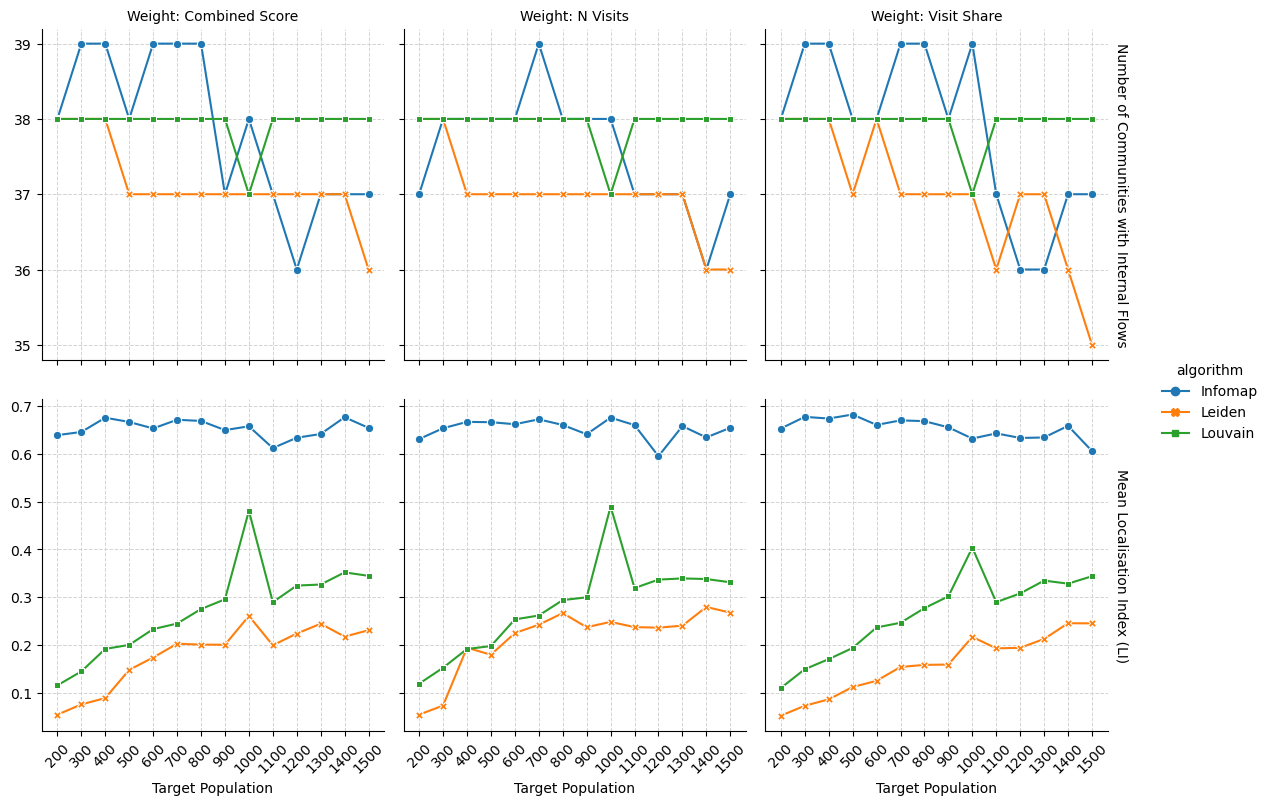

In [7]:
from matplotlib.ticker import MaxNLocator

# Prepare data for plotting
ncomm_plot_df = best_params_by_group.copy()
ncomm_plot_df["metric"] = "Number of Communities with Internal Flows"
ncomm_plot_df["value"] = ncomm_plot_df["n_communities_excl_zeros"]

li_plot_df = best_params_by_group.copy()
li_plot_df["metric"] = "Mean Localisation Index (LI)"
li_plot_df["value"] = li_plot_df["mean_LI"]

# Combine both metrics into a single DataFrame
plot_df = pd.concat([ncomm_plot_df, li_plot_df], ignore_index=True)

# Format labels for plotting
plot_df["algorithm"] = plot_df["algorithm"].str.title()
plot_df["weight_column"] = plot_df["weight_column"].str.replace("_", " ").str.title()

# Create line plot by algorithm, weighting strategy, and metric
g = sns.relplot(
    data=plot_df,
    x="target_pop",
    y="value",
    hue="algorithm",
    style="algorithm",
    col="weight_column",
    row="metric",
    kind="line",
    markers=True,
    dashes=False,
    height=4,
    aspect=1,
    facet_kws={"margin_titles": True, "sharey": "row"},
    legend="full"
)

x_ticks = np.arange(200, 1501, 100)

for i, ax in enumerate(g.axes.flat):
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, rotation=45, fontsize=10)

    row_idx = i // len(g.col_names)
    metric_label = g.row_names[row_idx]
    if "Communities" in metric_label:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.grid(True, color='lightgray', linestyle='--', linewidth=0.7)

# Set axis and facet titles
g.set_axis_labels("Target Population", "")
g.set_titles(col_template="Weight: {col_name}", row_template="{row_name}")

# Save and display the plot
plt.savefig(plots_dir / "best_model.png", dpi=300, bbox_inches="tight")
plt.show()


#### Generate a graph to illustrate how the community structure changes when using different tuning parameters.

Note: this graph shows the average outcomes and their ranges across all the combination of spatial scales (target_pop) and weighting scheme

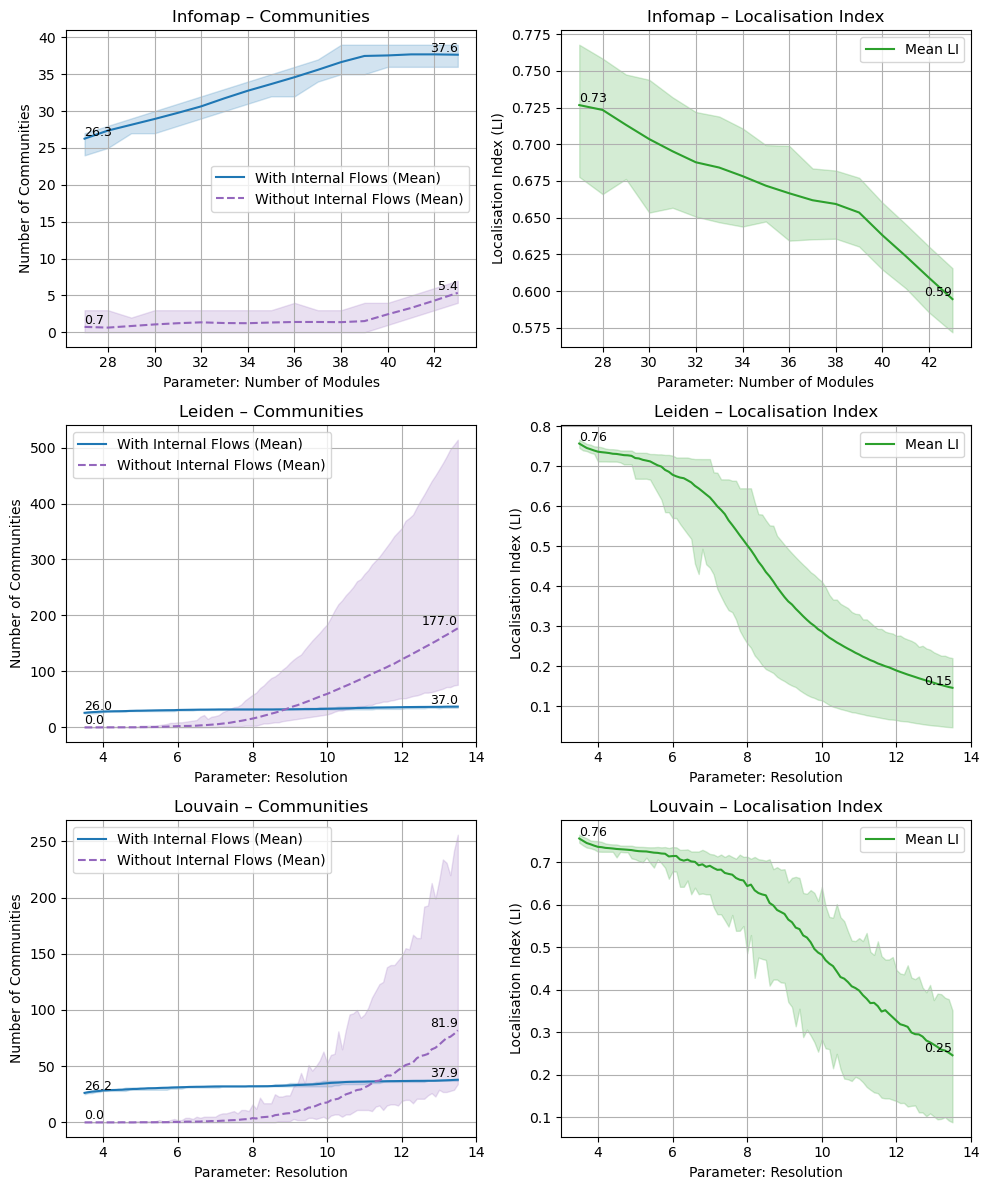

In [8]:
# Calculate number of communities without internal flows
merged_stats["no_internal_flows"] = merged_stats["n_communities"] - merged_stats["n_communities_excl_zeros"]

# Group by algorithm and param to compute summary statistics
agg_stats = (
    merged_stats
    .groupby(["algorithm", "param"])
    .agg(
        ncom_wif_mean=("n_communities_excl_zeros", "mean"),
        ncom_wif_min=("n_communities_excl_zeros", "min"),
        ncom_wif_max=("n_communities_excl_zeros", "max"),
        ncom_nif_mean=("no_internal_flows", "mean"),
        ncom_nif_min=("no_internal_flows", "min"),
        ncom_nif_max=("no_internal_flows", "max"),
        li_mean=("mean_LI", "mean"),
        li_min=("mean_LI", "min"),
        li_max=("mean_LI", "max"),
    )
    .reset_index()
)

# Get list of algorithms
algorithms = agg_stats["algorithm"].unique()

# Create subplot grid: one row per algorithm, two columns
fig, axes = plt.subplots(len(algorithms), 2, figsize=(10, 4 * len(algorithms)))

# Ensure axes is always a 2D array
if len(algorithms) == 1:
    axes = axes.reshape(1, 2)

for i, algo in enumerate(algorithms):
    df = agg_stats[agg_stats["algorithm"] == algo]
    x_vals = df["param"]

    # Set x-axis label depending on algorithm type
    x_label = "Parameter: Resolution" if algo in ["louvain", "leiden"] else "Parameter: Number of Modules"

    # Subplot 1: Number of communities
    ax1 = axes[i, 0]
    ax1.fill_between(x_vals, df["ncom_wif_min"], df["ncom_wif_max"], alpha=0.2, color="tab:blue")
    ax1.plot(x_vals, df["ncom_wif_mean"], label="With Internal Flows (Mean)", color="tab:blue")

    # Add text labels at start and end points
    ax1.text(x_vals.iloc[0], df["ncom_wif_mean"].iloc[0], f"{df['ncom_wif_mean'].iloc[0]:.1f}", 
             ha='left', va='bottom', fontsize=9)
    ax1.text(x_vals.iloc[-1], df["ncom_wif_mean"].iloc[-1], f"{df['ncom_wif_mean'].iloc[-1]:.1f}", 
             ha='right', va='bottom', fontsize=9)

    ax1.fill_between(x_vals, df["ncom_nif_min"], df["ncom_nif_max"], alpha=0.2, color="tab:purple")
    ax1.plot(x_vals, df["ncom_nif_mean"], label="Without Internal Flows (Mean)", color="tab:purple", linestyle="--")

    # Add text labels at start and end points
    ax1.text(x_vals.iloc[0], df["ncom_nif_mean"].iloc[0], f"{df['ncom_nif_mean'].iloc[0]:.1f}", 
             ha='left', va='bottom', fontsize=9)
    ax1.text(x_vals.iloc[-1], df["ncom_nif_mean"].iloc[-1], f"{df['ncom_nif_mean'].iloc[-1]:.1f}", 
             ha='right', va='bottom', fontsize=9)

    ax1.set_title(f"{algo.capitalize()} – Communities")
    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Number of Communities")
    ax1.grid(True)
    ax1.legend()

    # Subplot 2: Localisation Index
    ax2 = axes[i, 1]
    ax2.fill_between(x_vals, df["li_min"], df["li_max"], alpha=0.2, color="tab:green")
    ax2.plot(x_vals, df["li_mean"], label="Mean LI", color="tab:green")

    # Add text labels at start and end points
    ax2.text(x_vals.iloc[0], df["li_mean"].iloc[0], f"{df['li_mean'].iloc[0]:.2f}", 
             ha='left', va='bottom', fontsize=9)
    ax2.text(x_vals.iloc[-1], df["li_mean"].iloc[-1], f"{df['li_mean'].iloc[-1]:.2f}", 
             ha='right', va='bottom', fontsize=9)

    ax2.set_title(f"{algo.capitalize()} – Localisation Index")
    ax2.set_xlabel(x_label)
    ax2.set_ylabel("Localisation Index (LI)")
    ax2.grid(True)
    ax2.legend()

plt.tight_layout()
plt.savefig(plots_dir / "params_vs_ncomms_and_li_by_alg_range.png", dpi=300, bbox_inches="tight")
plt.show()


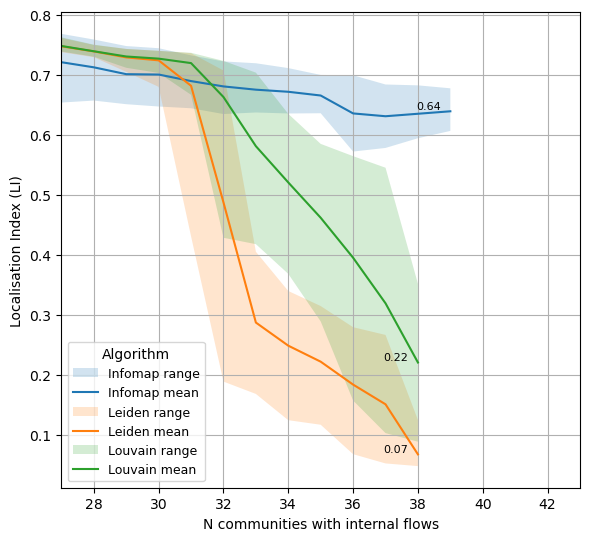

In [ ]:
# Step 1: Prepare plot
fig, ax1 = plt.subplots(1, 1, figsize=(6, 6), sharex=True)

merged_stats["algorithm"] = merged_stats["algorithm"].str.title()

# Step 2: One line per algorithm
for algorithm, group in merged_stats.groupby("algorithm"):
    # Group by number of communities with internal flows
    grouped = group.groupby("n_communities_excl_zeros")

    x_vals = sorted(grouped.groups.keys())
    li_mean = []
    li_min = []
    li_max = []

    for x in x_vals:
        li_vals = grouped.get_group(x)["mean_LI"]
        li_mean.append(li_vals.mean())
        li_min.append(li_vals.min())
        li_max.append(li_vals.max())

    # Plot shaded area for min–max
    ax1.fill_between(x_vals, li_min, li_max, alpha=0.2, label=f"{algorithm} range")

    # Plot mean line
    ax1.plot(x_vals, li_mean, label=f"{algorithm} mean")

    # Annotate start and end (add small horizontal shift inward)
    x_start = x_vals[0] + 2
    x_end = x_vals[-1] - 0.3
    #ax1.text(x_start, li_mean[0], f"{li_mean[0]:.2f}", ha='left', va='bottom', fontsize=8)
    ax1.text(x_end, li_mean[-1], f"{li_mean[-1]:.2f}", ha='right', va='bottom', fontsize=8)

# Step 3: Styling
ax1.set_xlabel("N communities with internal flows")
ax1.set_ylabel("Localisation Index (LI)")
ax1.set_xlim(27, 43)
ax1.grid(True)
ax1.legend(title="Algorithm", fontsize=9, title_fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig(plots_dir / "li_algorithms_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### Compare and identify the best spatial enforcement strategy by summarising mean LI and execution time

In [10]:
def format_df(df):
    long_df = df.melt(
    id_vars=["algorithm", "strategy"],
    value_vars=["mean_LI", "execution_time"],
    var_name="metric",
    value_name="value")
    
    agg_df = long_df.groupby(["algorithm", "metric", "strategy"])["value"].agg(['mean', 'std'])

    agg_df["formatted"] = agg_df.apply(lambda row: f"{row['mean']:.3f} ({row['std']:.3f})", axis=1)

    #Reshape into wide format: metrics as top-level columns, strategies as sub-columns
    formatted_df = agg_df["formatted"].unstack(level=[1, 2])

    return formatted_df

summary_stats_nz = summary_stats.loc[(summary_stats["exclude_zero_flows"]==False)&
                                     (summary_stats["enforce_spatial"]==True)&
                                     (summary_stats["param"]!="def")].copy()

formatted_df = format_df(summary_stats_nz)
formatted_df.to_excel(output_dir / "spatial_enforcement_comparison_overall.xlsx")

formatted_df

metric      execution_time                               mean_LI  \
strategy  min_impact_score strongest_connection min_impact_score   
algorithm                                                          
infomap      5.564 (6.044)        1.028 (0.496)    0.701 (0.026)   
leiden       1.646 (1.721)        1.062 (0.602)    0.701 (0.030)   
louvain      1.233 (0.957)        0.926 (0.467)    0.702 (0.025)   

metric                          
strategy  strongest_connection  
algorithm                       
infomap          0.703 (0.026)  
leiden           0.700 (0.032)  
louvain          0.702 (0.025)